# **Introducción al Modelado Continuo 2C 2026** - Clase 1

---

Creado por Manuel Delgado y Agustín Brusco.



## Introducción (aunque no al Modelado Continuo)

En la materia vamos a resolver problemas que no tienen necesariamente una solución analítica conocida, así que necesitamos aprender métodos numéricos para poder atacar este tipo de problemas.

# Raíces

A veces puede parecer que encontrar raíces es un problema muy matemático o quizá que está poco motivado _¿Para qué quiero encontrar una raíz?_

En la materia tenemos una motivación inicial muy clara: encontrar los puntos fijos de las ecuaciones diferenciales que estudiemos.

Dada una ecuación diferencial

$$\dot{x} = F(x)$$

Queremos encontrar $x^*$ tal que

$$F(x^*) = 0$$

En muchos casos no se pueden hallar las raíces de $F$ analíticamente, por lo que hará falta utilizar métodos iterativos para encontrarlas.

¡Existen muchos de estos métodos! Pero solo tenemos tiempo de analizar un par.

## Ejercicio 1 - Método de bisección (la busqueda binaria)

Este es el método más directo y sencillo.

Si tenemos una función $f$ continua en un intervalo $[a,b]$ tal que $f(a) \cdot f(b) < 0$, es decir que hay un cambio de signo en el intervalo, entonces el método iterativo de bisección converge.

El método se define de la siguiente forma:

Paso 1)  Empiezo en $x_0 = \frac{a+b}{2}$

Paso 2)  Comparo el signo de $f(x_0)$ con el de $f(a)$ y $f(b)$ y re-definimos $a$ o $b$:
* Si $f(x_0)\cdot f(a) > 0 \to a_1 = x_0, b_1 = b \; \, $ ($f$ tiene el mismo signo en $a$ que en $x_0$)
* Si $f(x_0)\cdot f(b) > 0 \,\to a_1 = a, \; \, b_1 = x_0$ ($f$ tiene el mismo signo en $b$ que en $x_0$)
* Si $f(x_0) = 0$ termino ($x_0$ es raíz)

Paso 3)  Si no terminé, repito desde el paso 1 con los nuevos $a_1$ y $b_1$ hasta que halle una raíz, realice $N$ iteraciones o hasta que se cumpla algún criterio (foco de la siguiente sección).

La siguiente figura muestra una visualización de un par de iteraciones del método:


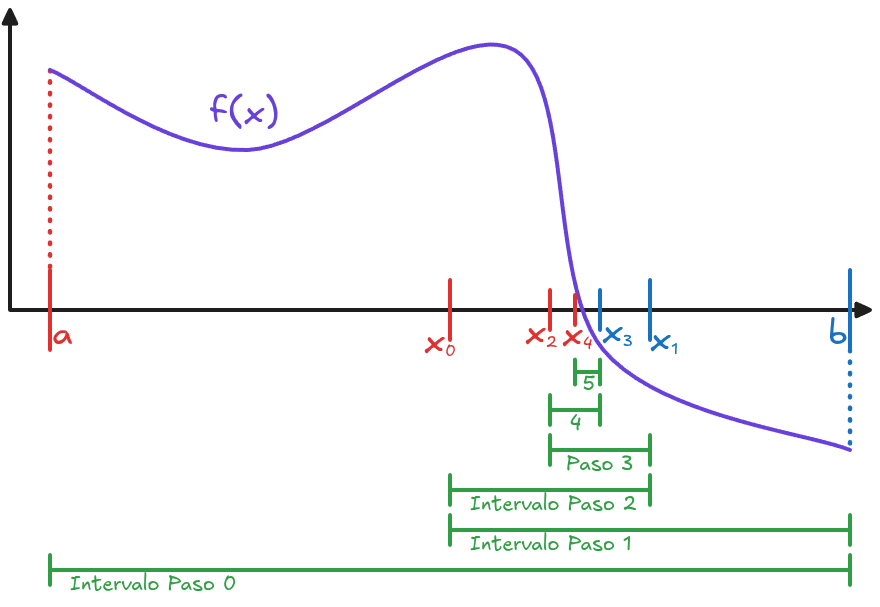

### Convergencia del método

Si se fijan, al menos gráficamente, no parece que vayamos a converger *exactamente* a cero, sino que nos vamos a acercar tanto como número de pasos/iteraciones hagamos.

Para que nuestros códigos no tarden infinito e iteremos para siempre, definimos una tolerancia. Un error que estamos dispuestos a aceptar sobre nuestra estimación de la raíz.

Hay varias maneras de estimar/definir un error. Estas son algunas de las más comunes:


*   El error absoluto:  $$\mid x_{n+1} - x_n \mid \leq \text{Tol.}$$
*   El error relativo:  $$\frac{\mid x_{n+1} - x_n \mid}{\mid x_n \mid} \leq \text{Tol.}$$
*   El módulo de $f(x_n)$: $$\mid f(x_n) \mid \leq \text{Tol.}$$

Ustedes pueden usar la estimación del error que más les guste o les resulte más intuitiva. Ahora, independientemente de como definan su error, van a tener que definir una tolerancia, que será un número completamente arbitrario y elegido por ustedes y dependerá del problema que estén resolviendo y qué tan dispuestos estén a tener una mayor o menor tolerancia.


---

### Convergencia del método de bisección

Todo lo mencionado arriba con respecto a la tolerancia refiere a cómo vamos a tener que programar nuestros métodos, pero para nada nos dice sobre que tan "bueno" o que tan "rápido" converge el método de bisección.

En particular, se puede demostrar (pero jamás lo haremos) que el método de bisección tiene convergencia lineal, lo que implica que

$$e_n = \mid x_n - r \mid \leq C \mid x_{n-1} -r \mid = e_{n-1}$$

donde $r$ es la raíz real. Lo que nos dice esto es que a cada paso del método, el error se reduce proporcionalmente al error del paso anterior.

Pueden tener más o menos noción sobre que tan "bueno" o "rápido" es que la convergencia del método sea lineal, pero al menos con respecto a los otros métodos de este notebook, este método es lento, pero seguro! Va a encontrar una raíz siempre que se satisfagan sus condiciones.

### Inciso $a$ - Implementando el método

Implemente una función en Python que reciba una función $f(x)$, un número $a$, un número $b$, un número $N$ y que realice $N$ iteraciones del método de bisección en el intervalo $(a, b)$ para luego devolver tanto la raíz encontrada junto con alguna de las maneras de definir la precisión de la misma.

Implemente una comprobación en la función de que existe una raíz en el intervalo seleccionado, chequeando que $f(a) f(b) < 0$.

¿Por qué no hace falta que la función reciba el paso $x_0$ sobre el cual empezar?

### Inciso $b$ - Probando el método

Utilizando la función que implementó en el inciso anterior, encuentre las raíces de las siguientes funciones en sus correspondientes intervalos:

* $f(x) = x^2-4x-2$ en el intervalo $x \in [-1,1]$
* $f(x) = x^2-4x-2$ en el intervalo $x \in [-1,5]$
* $f(x) = \text{ln}(x) \, \text{cos}(x)$  en el intervalo $x \in [5,10]$
* $f(x) = \text{arctan}(x)\,\;\;\;$  en el intervalo $x \in [-8,5]$

**Antes de aplicar apresuradamente el método, grafique la función en el correspondiente intervalo o en un intervalo de su elección.**

### Preguntas Extra (opcional: interrogue a un docente la siguiente clase)

 i. Si no se cumple el criterio $f(a)f(b) < 0$, ¿se garantiza que no hay una raíz en el intervalo?

 ii. Antes de ejecutar nada: si el intervalo inicial mide $b-a$ y quiero la raíz con una precisión de $10^{-6}$, ¿cuántas iteraciones necesito? ¿La respuesta depende de qué función sea $f$?

 iii. Este método puede encontrar ciertas raíces con exactitud. ¿De qué forma (en función de $a$ y $b$) son las raíces que este método puede encontrar de forma exacta?

## Ejercicio 2 - Método de Newton-Raphson

Supongamos que tenemos una función $f$ continua y derivable en un intervalo $[a,b]$, entonces el método de Newton-Raphson lo que hace es trazar tangentes y buscar sus ceros

Paso 1) Elegimos $x_0 \in [a,b]$

Paso 2) Calculamos $$x_{n+1} = x_n - \frac{f(x_n)}{f^{'}(x_n)}$$


La siguiente imagen muestra una visualización de un par de pasos del método:

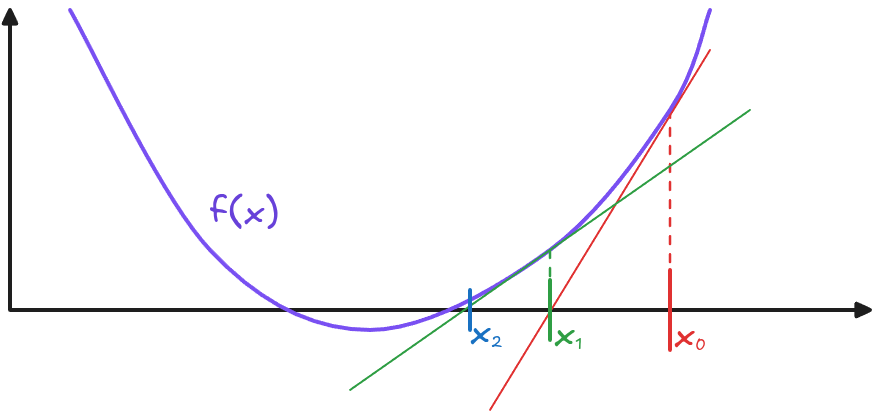

### Algunas precauciones



*   Este método no siempre converge.
*   No siempre está bien definido.
*   Hay que poder calcular $f^{'}$, que no siempre es fácil o factible de hacer.


### Casos de convergencia global

El método de N-R no siempre converge, pero hay algunos casos donde el método converge globalmente, es decir, no importa qué $x_0$ elija para empezar a iterar, el método siempre encuentra la raíz.

La siguiente imagen muestra los 4 casos de convergencia global:

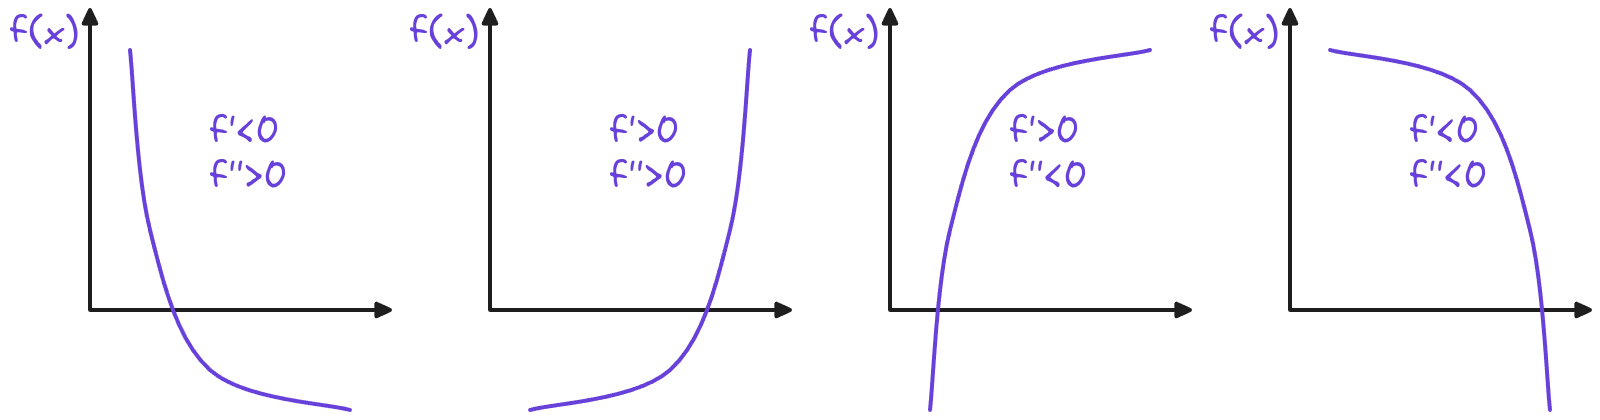


### Convergencia del método

Independientemente de si la convergencia es global o no, si el método de Newton-Raphson converge, la convergencia es cuadrática, lo que quiere decir que:

$$e_n = \mid x_n - r \mid  \leq C \mid x_{n-1}-r \mid^2 = C e_{n-1}^2$$

Esto hace que el método converja muy rápido! Ya que con cada paso el error se achica cuadráticamente. Como ejemplo, si en el paso inicial $e_0 \approx 0.1 \rightarrow e_1 \approx 0.01$.


### Comentarios extras

Hay más métodos para encontrar raíces e incluso se pueden conbinar. Algo que podrían hacer es implementar un método que realice un par iteraciones del método de bisección y a partir de una cierta tolerancia cambiar al método de Newton-Raphson para que converja más rápido.

Además, ¡Este método también sirve para problemas de optimización! Que son de los que les gustan a ustedes :)

Los problemas de optimización que consisten en buscar cuales son los parámetros que minimizan funciones, como puede ser realizar cuadrados mínimos o entrenar redes neuronales, pueden pensarse como buscar los ceros del gradiente de la función que queremos minimizar, que sabemos que son los puntos críticos de la función.

Entonces el problema consiste en encontrar $\vec{x}^*$ tal que $\vec{\nabla} f(\vec{x}^*)= 0$ y el método iterativo resulta en:

$$ \vec{x}_{n+1} = \vec{x}_n - H^{-1}(\vec{x}_n) \vec{\nabla} f (\vec{x}_n)$$


donde $H^{-1}$ es la inversa del Hessiano de la función $f$. Esto también implica, por si no fue obvio, que el método de Newton-Raphson puede generalizarse para hallar los ceros de una función en problemas multidimensionales.



### Inciso $a$ - Implementando el método


Implemente una función en Python que reciba una función $f(x)$, la derivada de la función $f'(x)$, un número $x_0$, un número $N$ y que realice $N$ iteraciones del método de Newton-Raphson para luego devolver tanto la raíz encontrada junto con alguna de las maneras de definir la precisión de la misma.

Recuerde que el método iterativo consiste en calcular:

$$
x_{n+1} = x_n-\frac{f(x_n)}{f^{'}(x_n)}
$$


### Inciso $b$ - Probando el método

Utilizando la función que implementó en el inciso anterior, encuentre las raíces de las siguientes funciones en sus correspondientes intervalos:

* $f(x) = x^2-4x-2$ en el intervalo $x \in [-1,5]$ con $x_0 = 2$

* $f(x) = \text{arctan}(x)\,\;\;\;$  en el intervalo $x \in [-5,8]$ con $x_0 = 4$

**¿Converge en todos los casos? ¿Por qué cree que podría ser?** Pruebe distintos valores de $x_0$ para los casos en que no converja el método.

### Preguntas Extra (opcional: interrogue a un docente la siguiente clase)

i. Dibujá el gráfico de una función tal que, para algún $x_0$, los $x_n$ oscilarían entre dos (o más?) valores sin converger a la raíz. ¿Qué tiene en común con $\arctan(x)$ del punto anterior?

ii. Este método puede usarse también para encontrar raíces de funciones complejas $f:\mathbb{C}\to\mathbb{C}$ pero ahí la convergencia de cada punto a una raíz tiene propiedades fractales. Más tarde en sus casas búsquen ["Fractales de Newton"](https://es.wikipedia.org/wiki/Fractal_de_Newton) y/o vean [este video](https://youtu.be/-RdOwhmqP5s?si=3FOJ-c85PTxsN313) de 3Blue1Brown (tiene subtítulos en español!).

## Ejercicio 3 - Comparando los métodos

### Inciso $a$ - Comparando los errores

Modifique las funciones de los ejercicios anteriores para ahora que guarden listas con cada uno de los pasos $x_n$ junto con su respectivo error y luego grafique los errores de cada método en función del número de iteraciones, para un caso en que ambos métodos converjan.

**Consejo**: para entender mejor este gráfico puede ser util graficar el eje $\hat{y}$ en escala logarítmica. Esto se puede hacer agregando la línea `plt.yscale("log")` al gráfico.




### Inciso $b$ - Si te quedaste con ganas de visualizar los métodos...

En un caso en que ambos métodos converjan, graficá las secuencias $x_n$ para cada uno de los métodos en función del número de pasos.

Después, si te quedas con ganas y tiempo, armá código que genere plots cómo los de la explicación de cada método. La idea es que muestren: la función $f(x)$, los valores de $x_n$ y en cada caso, algún elemento visual que indíque la relación entre $x_{n-1}$ y $x_{n}$ en ese algoritmo.

**Consejo:** Elija la función, el intervalo y/o el $x_0$ que hagan más claro el gráfico.